In [1]:
!	pip install interpret
!	pip install sklearn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 19.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.2/45.2 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 43.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 46.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 63.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 53.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.1/780.1 kB 32.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.7/101.7 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 31.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.0/228.0 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 12.1 MB/s eta 0:00:00
  Created wheel for dash-cytoscape: filename=dash_cytoscape-1.0.2-py3-none-any.whl size=40

In [2]:
import numpy as np
import pandas as pd
from interpret.glassbox import ExplainableBoostingRegressor as EBR
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Lasso, lasso_path
# Read in ALS data (analysis adapted from "Computer Age Statistical Inference")
url = 'https://hastie.su.domains/CASI_files/DATA/ALS.txt'
als = pd.read_csv(url, delim_whitespace=True)
als.head() # inspect first few rows

/tmp/ipython-input-2911182135.py:8: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  als = pd.read_csv(url, delim_whitespace=True)


,testset,dFRS,Onset.Delta,Symptom.Speech,Symptom.WEAKNESS,Symptom.OTHER,Symptom.Swallowing,Symptom.GAIT_CHANGES,Symptom.Atrophy,Symptom.Cramps,...,max.slope.bp.systolic,min.slope.bp.systolic,last.slope.bp.systolic,mean.slope.bp.systolic,num.slope.bp.systolic.visits,sum.slope.bp.systolic,first.slope.bp.systolic.date,meansquares.slope.bp.systolic,sd.slope.bp.systolic,slope.bp.systolic.slope
0,True,-0.915388,-1181,1,0,0,1,0,0,0,...,0.981828,-8.300909,0.000000,-2.439694,3,-7.319081,5.5,23.289693,4.163843,5.003010
1,True,-0.107931,-1324,0,1,0,0,0,0,0,...,0.000000,-9.818280,-9.818280,-4.909140,2,-9.818280,18.0,48.199307,4.909140,-8.920469
2,True,-0.557448,-1061,0,0,0,0,0,0,0,...,6.522143,-5.533939,6.522143,0.494102,2,0.988203,11.0,36.581416,6.028041,14.677878
3,True,-0.296461,-1736,0,1,0,0,0,0,0,...,55.800556,-87.928148,10.145556,-8.606468,7,-60.245275,4.5,1842.174361,42.048818,41.458842
4,True,-1.087024,-354,1,0,0,0,0,0,0,...,6.917424,-10.870238,6.917424,-1.317605,3,-3.952814,6.0,55.337611,7.321307,3.759702


In [3]:
# Split into train/test (and drop test set indicator)
als_trn = als[als['testset'] == False].drop('testset', axis=1)
als_tst = als[als['testset'] == True].drop('testset', axis=1)
# Separate predictors from response
X_trn = als_trn.drop('dFRS', axis=1)
X_tst = als_tst.drop('dFRS', axis=1)
y_trn = als_trn['dFRS']
y_tst = als_tst['dFRS']

In [6]:
# Fit an EBM
ebm = EBR(inner_bags=10, outer_bags=10,interactions=10)

In [7]:
ebm.fit(X_trn, y=y_trn)

ExplainableBoostingRegressor(inner_bags=10, interactions=10, outer_bags=10)

In [8]:
# Convert train/test sets into their associated term contributions
X_trn_tc = ebm.eval_terms(X_trn)
X_tst_tc = ebm.eval_terms(X_tst)
# Fit LASSO path and grab alpha values
ebm_lasso_path = lasso_path(X_trn_tc, y=y_trn, positive=True)
alphas = ebm_lasso_path[0]
# Fit a LASSO for each alpha; compute test MSE and number of non-zero coefs
mses = []
nterms = []
for alpha in alphas:
    _lasso = Lasso(alpha=alpha, positive=True)
    _lasso.fit(X_trn_tc, y=y_trn)
    _mse = mean_squared_error(y_tst, y_pred=_lasso.predict(X_tst_tc))
    mses.append(_mse)
    nterms.append(np.count_nonzero(_lasso.coef_))

In [9]:
# Fit a LASSO using the "best" alpha
alpha_best = alphas[np.argmin(mses)]
ebm_lasso = Lasso(alpha=alpha_best, positive=True)
ebm_lasso.fit(X_trn_tc, y=y_trn)

Lasso(alpha=np.float64(0.0002798622605816508), positive=True)

In [10]:
np.count_nonzero(ebm_lasso.coef_) # number of non-zero coefficients

33

In [11]:
# Compare intercepts
ebm.intercept_, ebm_lasso.intercept_

(-0.6802357522044189, np.float64(-0.6802357522044189))

In [12]:
# Rescale terms using LASSO coefficients
for idx, x in enumerate(ebm.term_names_):
    ebm.scale(idx, factor=ebm_lasso.coef_[idx])
    ebm.intercept_ = float(ebm_lasso.intercept_) # also update intercept

In [13]:
# Check term importance scores
term_imp = ebm.term_importances()
np.count_nonzero(term_imp) # terms with non-zero coefficients

33

In [14]:
len(term_imp) - np.count_nonzero(term_imp) # terms with coefficient of zero

346

In [15]:
# Remove unused terms (e.g., those with zero importance)
ebm.sweep()
len(ebm.term_names_) # sanity check (should only have 19 terms now)

33

In [16]:
# Check term importance scores for reduced EBM (should only have 19 terms not
# counting the intercept)
new_term_vi = pd.DataFrame({
'term' : ebm.term_names_, 'importance' : ebm.term_importances()
})
new_term_vi.sort_values(by=['importance'], ascending=False)

,term,importance
25,Onset.Delta & meansquares.alsfrs.score,0.056941
29,Onset.Delta & last.slope.weight,0.051021
27,Onset.Delta & meansquares.bp.diastolic,0.050649
5,alsfrs.score.slope,0.042827
31,Onset.Delta & meansquares.slope.weight,0.036576
32,Onset.Delta & last.slope.bp.systolic,0.031113
28,Onset.Delta & mean.slope.svc.liters,0.026678
6,last.speech,0.025616
4,last.alsfrs.score,0.021445
11,meansquares.climbing.stairs,0.021080


# plot section

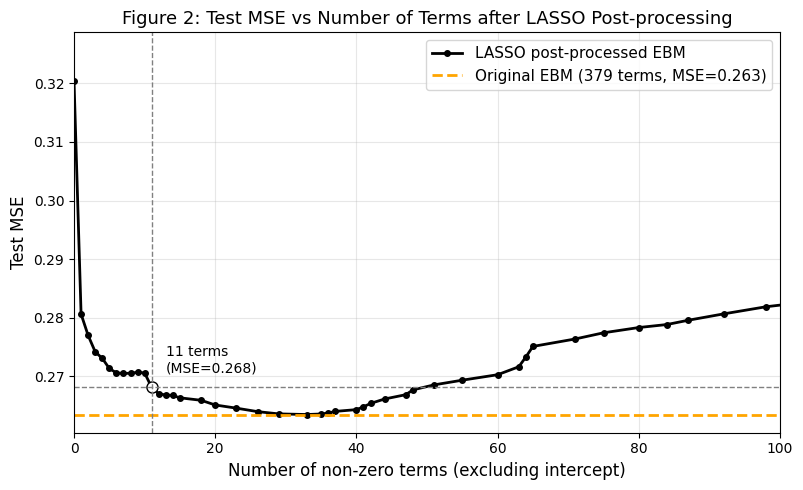

In [17]:
from matplotlib import pyplot as plt
from collections import defaultdict

# Step 1: Calculate the test MSE of the original EBM (if not already calculated)
y_pred_ebm = ebm.predict(X_tst)
original_ebm_mse = mean_squared_error(y_tst, y_pred_ebm)

# Step 2: Sort by nterms in ascending order (LASSO path defaults to alpha descending,
# which usually means nterms ascending, but sorting is safer).
# Note: Multiple alphas might yield the same nterm; we select the minimum MSE among them (deduplication).
mse_by_nterm = defaultdict(list)
for n, m in zip(nterms, mses):
    mse_by_nterm[n].append(m)

# Take the minimum test MSE for each term count (robust approach)
unique_nterms = sorted(mse_by_nterm.keys())
min_mses = [min(mse_by_nterm[n]) for n in unique_nterms]

# Step 3: Plotting
plt.figure(figsize=(8, 5))

# Main curve: LASSO path (Test MSE vs # terms)
plt.plot(unique_nterms, min_mses,
         marker='o', markersize=4, linewidth=2, color='black',
         label='LASSO post-processed EBM')

# Original EBM horizontal line (379 terms)
plt.axhline(y=original_ebm_mse,
            color='orange', linestyle='--', linewidth=2,
            label=f'Original EBM (379 terms, MSE={original_ebm_mse:.3f})')

# Find the optimal point: Minimum number of terms where MSE <= original_ebm_mse + tolerance (e.g., 0.005)
tolerance = 0.005  # Allowance for a slight increase in MSE
valid_indices = [i for i, (n, m) in enumerate(zip(unique_nterms, min_mses))
                if m <= original_ebm_mse + tolerance]

if valid_indices:
    # Select the point with the minimum number of non-zero terms
    best_idx = min(valid_indices, key=lambda i: unique_nterms[i])
    best_n = unique_nterms[best_idx]
    best_mse = min_mses[best_idx]

    # Highlight the best point (e.g., 19 terms)
    plt.plot(best_n, best_mse, 'ko', markersize=8, markerfacecolor='white')
    plt.axhline(y=best_mse, color='gray', linestyle='--', linewidth=1)
    plt.axvline(x=best_n, color='gray', linestyle='--', linewidth=1)

    # Add text annotation
    plt.text(best_n + 2, best_mse + 0.002,
             f'{int(best_n)} terms\n(MSE={best_mse:.3f})',
             fontsize=10, ha='left', va='bottom')

# Decoration
plt.xlabel('Number of non-zero terms (excluding intercept)', fontsize=12)
plt.ylabel('Test MSE', fontsize=12)
plt.title('Figure 2: Test MSE vs Number of Terms after LASSO Post-processing', fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Optional: Limit x-axis range to focus on the sparse region (since 379 terms is too wide)
plt.xlim(0, min(100, max(unique_nterms) + 5))

# Show or save the plot
plt.show()
# plt.savefig('figure2.png', dpi=300, bbox_inches='tight')